In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import binom
import pandas as pd
import math
import pickle
import statsmodels.stats.power
import statsmodels.api as sm
import statsmodels.stats.multitest as mt
from sklearn import datasets

## Power

In [2]:
mu_0 = 30
mu_a = 32
alpha = 0.05
sigma = 4
n = 16
z = stats.norm.ppf(1 - alpha)
print(stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc=mu_0, scale=sigma/np.sqrt(n)))
print(stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc=mu_a, scale=sigma/np.sqrt(n)))

0.049999999999999954
0.6387600313123348


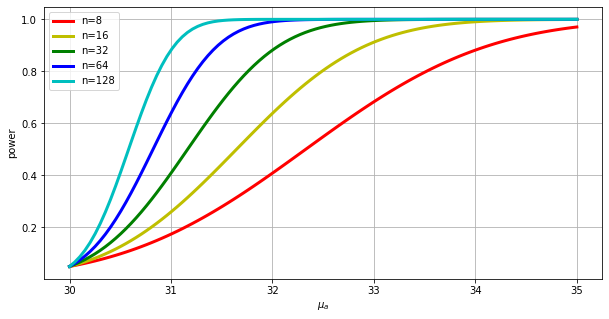

In [3]:
def power(mu_a, n):
    mu_0, alpha, sigma = 30, 0.05, 4
    z = stats.norm.ppf(1 - alpha)
    return stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc=mu_a, scale=sigma/np.sqrt(n))

mu_a = np.linspace(30, 35, 100)

plt.figure(figsize=(10,5))
[plt.plot(mu_a, power(mu_a, n), lw=3, color=c) 
     for n,c in [(8, 'r'), (16, 'y'), (32, 'g'), (64, 'b'), (128, 'c')]
]
plt.grid()
plt.legend(['n=8', 'n=16', 'n=32', 'n=64', 'n=128'])
plt.xlabel('$\mu_a$')
plt.ylabel('power')
plt.show()

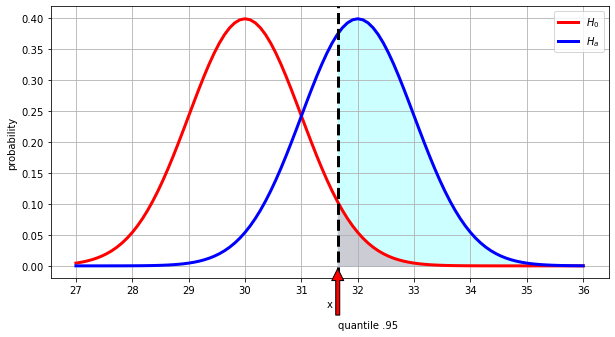

In [4]:
# probabilitatea de a accepta ipoteza nulă H0 atunci când ea este falsă -> type II error (beta)
# H0: mu=0, Ha: mu<>0

# 1 - probabilitatea de a accepta ipoteza nulă H0 atunci când ea este falsă =
# = probabilitatea de a rejecta ipoteza nulă H0 atunci când ea este falsă (1 - beta) = power

mu_0 = 30
mu_a = 32
sigma = 4
n = 16
alpha = 0.05

x = np.linspace(27, 36, 100)
y_0 = stats.norm.pdf(x, loc=mu_0, scale=sigma/np.sqrt(n))
y_a = stats.norm.pdf(x, loc=mu_a, scale=sigma/np.sqrt(n))
x_black = stats.norm.ppf(0.95, loc=mu_0, scale=sigma/np.sqrt(n))
x1 = np.linspace(x_black, 36, 100)

plt.figure(figsize=(10,5))
plt.plot(x, y_0, lw=3, c='r')
plt.plot(x, y_a, lw=3, c='b')
plt.legend(['$H_0$', '$H_a$'])
plt.grid()
plt.xticks(np.linspace(27, 36, 10))
plt.xlabel('x')
plt.ylabel('probability')
plt.axvline(x=x_black, c='k', linestyle='--', lw=3)
plt.annotate('quantile .95', 
            xy=(x_black, 0), 
            xytext=(x_black, -.1), 
            arrowprops = dict(facecolor='red', shrink=0.05))
plt.fill_between(x1, stats.norm.pdf(x1, loc=mu_0, scale=sigma/np.sqrt(n)), color="pink")
plt.fill_between(x1, stats.norm.pdf(x1, loc=mu_a, scale=sigma/np.sqrt(n)), color="cyan", alpha=0.2)
plt.show()

In [5]:
print(stats.norm.sf(x_black, loc=mu_a, scale=sigma/np.sqrt(n)))
print(statsmodels.stats.power.normal_power(
    effect_size=(mu_a - mu_0)/sigma, 
    nobs=16, alpha=0.05, alternative='larger')
)

0.6387600313123348
0.638760031312335


In [6]:
print('mu_0: %d, mu_a: %d' % (mu_0, mu_a))
print('sigma: ', sigma)
print('power: ', statsmodels.stats.power.ttest_power(
    effect_size=(mu_a - mu_0)/sigma, 
    nobs=16, alpha=0.05, alternative='larger'))

mu_0: 30, mu_a: 32
sigma:  4
power:  0.6040328683316007


In [7]:
print(statsmodels.stats.power.tt_solve_power(
    effect_size=(mu_a - mu_0)/sigma, 
    alpha=0.05, nobs=16, alternative='larger'))
print(statsmodels.stats.power.tt_solve_power(
    effect_size=(mu_a - mu_0)/sigma, 
    alpha=0.05, power=0.6040328, alternative='larger'))

0.6040328683316007
15.999997299353062


# Multiple tests

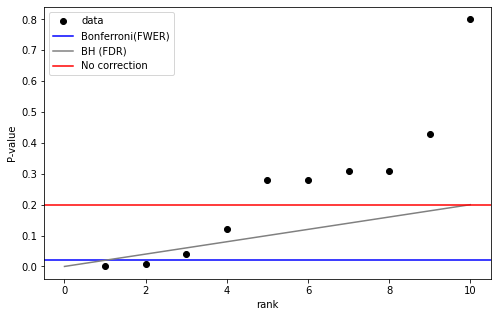

In [8]:
rank = np.array(range(10)) + 1
pValue = np.array([0.001, 0.007, 0.04, 0.12, 0.28, 0.28, 0.31, 0.31, 0.43, 0.8])
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(rank, pValue, 'o', c='k')
ax.axhline(y=0.02, c='b')
ax.plot([0, 10], [0., .2], c='gray')
ax.axhline(y=0.2, c='r')
ax.set_xlabel('rank')
ax.set_ylabel('P-value')
ax.legend(['data', 'Bonferroni(FWER)', 'BH (FDR)', 'No correction'])
plt.show()

In [9]:
n = 1000
pValues = np.zeros(n)
for i in range(n):
    x = np.random.randn(20)
    y = np.random.randn(20)
    x = sm.add_constant(x)
    est = sm.OLS(y, x).fit()
    pValues[i] = est.pvalues[1]
    
print('no correction: ', np.sum(pValues < 0.05))

no correction:  44


In [10]:
res = mt.multipletests(pValues, method='bonferroni')
print('Bonferroni correction: ', np.sum(res[1] < 0.05))

res = mt.multipletests(pValues, method='fdr_bh')
print('Benjamini/Hochberg correction: ', np.sum(res[1] < 0.05))

Bonferroni correction:  0
Benjamini/Hochberg correction:  0


In [11]:
# exemplu pentru care coeficientul w al regresiei liniare este:
# 0 pentru primele 500 de situatii construite
# 2 pentru urmatoarele
n = 1000
pValues = np.zeros(n)
for i in range(n):
    x = np.random.randn(20)
    y = np.random.randn(20) if i < n//2 else (np.random.randn(20) + 2*x)
    x = sm.add_constant(x)
    est = sm.OLS(y, x).fit()
    pValues[i] = est.pvalues[1]
    
print('no correction:', np.sum(pValues < 0.05))
res = mt.multipletests(pValues, method='bonferroni')
print('corectie FWER:' , np.sum(res[1] < 0.05))

no correction: 529
corectie FWER: 481


In [12]:
df = pd.DataFrame({
    'trueStatus': ['zero'] * 500 + ['not zero'] * 500,
    'pValue': pValues
})
pd.crosstab(df.pValue < 0.05, df.trueStatus)

trueStatus,not zero,zero
pValue,,
False,0,471
True,500,29


In [13]:
df = pd.DataFrame({
    'trueStatus': ['zero'] * 500 + ['not zero'] * 500,
    'pValueAdjusted': mt.multipletests(pValues, method='bonferroni')[1]
})
pd.crosstab(df.pValueAdjusted < 0.05, df.trueStatus)

trueStatus,not zero,zero
pValueAdjusted,,
False,19,500
True,481,0


In [14]:
df = pd.DataFrame({
    'trueStatus': ['zero'] * 500 + ['not zero'] * 500,
    'pValueAdjusted': mt.multipletests(pValues, method='fdr_bh')[1]
})
pd.crosstab(df.pValueAdjusted < 0.05, df.trueStatus)

trueStatus,not zero,zero
pValueAdjusted,,
False,0,488
True,500,12


In [15]:
adjustBonf = mt.multipletests(pValues, method='bonferroni')[1]
adjustBH = mt.multipletests(pValues, method='fdr_bh')[1]

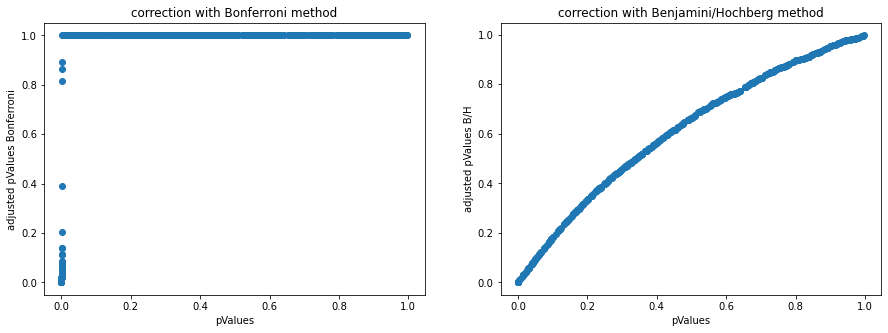

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize=(15, 5))
ax1.plot(pValues, adjustBonf, 'o')
ax1.set_xlabel('pValues')
ax1.set_ylabel('adjusted pValues Bonferroni')
ax1.set_title('correction with Bonferroni method')
ax2.plot(pValues, adjustBH, 'o')
ax2.set_xlabel('pValues')
ax2.set_ylabel('adjusted pValues B/H')
ax2.set_title('correction with Benjamini/Hochberg method')
plt.show()

## Bootstrap

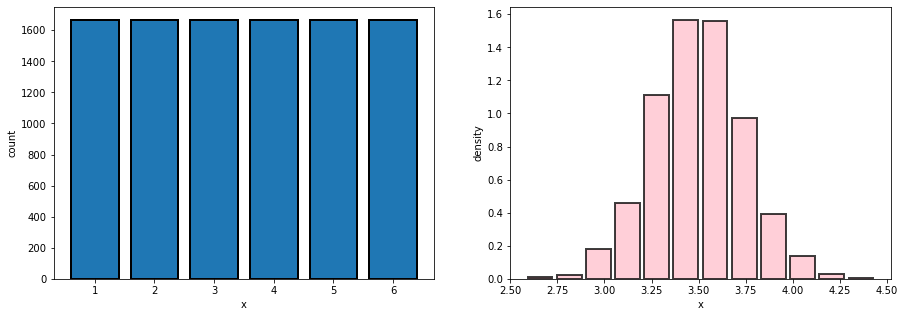

In [17]:
from functools import reduce

def roll(n):
    nosim = 10000
    x = np.random.randint(low=1, high=7, size=(nosim, n))
    return np.mean(x, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
kwargs = dict(rwidth=0.85, density=True, alpha=0.75, ec='k', linewidth=2)

ax1.bar(range(1, 7), [10000/6] * 6, linewidth=2, edgecolor='k')
ax1.set_xlabel('x')
ax1.set_ylabel('count')
ax2.hist(roll(50), bins=12, color='pink', **kwargs)
ax2.set_xlabel('x')
ax2.set_ylabel('density')
plt.show()

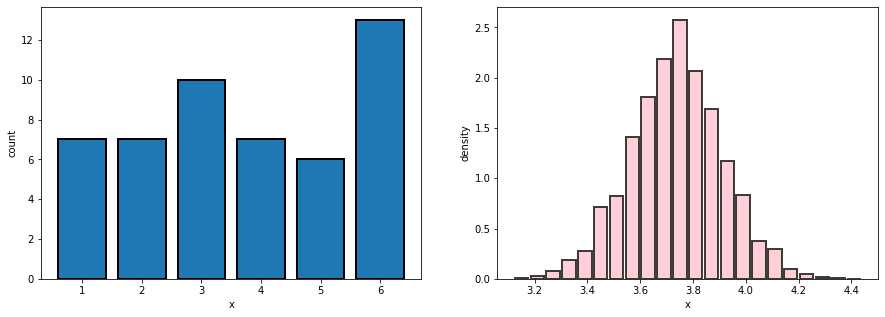

In [18]:
x = np.random.randint(low=1, high=7, size=(50))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
kwargs = dict(rwidth=0.85, density=True, alpha=0.75, ec='k', linewidth=2)

def roll(x, n):
    nosim = 10000
    x = np.random.choice(x, size=(nosim, n))
    return np.mean(x, axis=1)

l = [sum(np.array(x) == i) for i in range(1, 7)]

ax1.bar(range(1, 7), l, linewidth=2, edgecolor='k')
ax1.set_xlabel('x')
ax1.set_ylabel('count')
ax2.hist(roll(x, 100), bins=22, color='pink', **kwargs)
ax2.set_xlabel('x')
ax2.set_ylabel('density')
plt.show()

In [19]:
father_son = pd.read_csv('father_son.csv')
father_son.head()

,Unnamed: 0,fheight,sheight
0,1,65.04851,59.77827
1,2,63.25094,63.21404
2,3,64.95532,63.34242
3,4,65.75250,62.79238
4,5,61.13723,64.28113


D:\Anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


deviatia standard:  0.1035615867265876
quantila 2.5%: 67.552325
quantila 97.5%: 67.94335


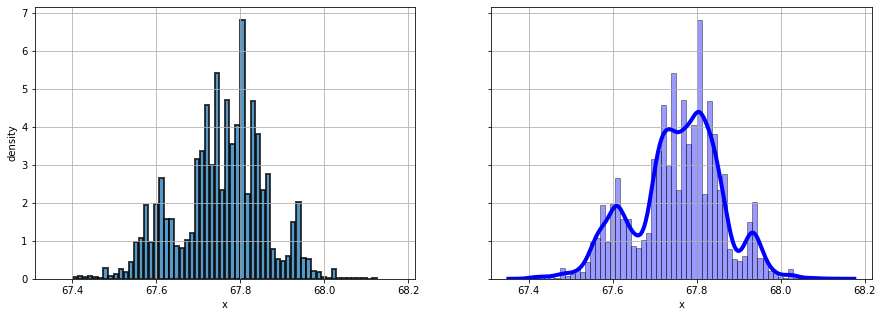

In [20]:
import seaborn

# vezi https://towardsdatascience.com/histograms-and-density-plots-in-python-f6bda88f5ac0

x = father_son.fheight.values
n, nosims = len(x), 10000
resamples = np.random.choice(x, size=(nosims, n), replace=True)
resampledMedians = np.median(resamples, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True, sharex=True)
kwargs = dict(rwidth=0.85, density=True, alpha=0.75, ec='k', linewidth=2)
ax1.hist(resampledMedians, **kwargs, bins=60)
ax1.grid()
ax1.set_xlabel('x')
ax1.set_ylabel('density')
seaborn.distplot(resampledMedians, hist=True, kde=True, bins=60, ax=ax2,
    color = 'blue',  hist_kws={'edgecolor':'black'}, kde_kws={'linewidth': 4})
ax2.grid()
ax2.set_xlabel('x')

print('deviatia standard: ', np.std(resampledMedians))
print('quantila 2.5%:', np.quantile(resampledMedians, 0.025))
print('quantila 97.5%:', np.quantile(resampledMedians, 0.975))
plt.show()


In [21]:
insect_sprays = pd.read_csv('insect_sprays.csv')
print(insect_sprays)
insect_sprays.head()

    Unnamed: 0  count spray
0            1     10     A
1            2      7     A
2            3     20     A
3            4     14     A
4            5     14     A
..         ...    ...   ...
67          68     10     F
68          69     26     F
69          70     26     F
70          71     24     F
71          72     13     F

[72 rows x 3 columns]


,Unnamed: 0,count,spray
0,1,10,A
1,2,7,A
2,3,20,A
3,4,14,A
4,5,14,A


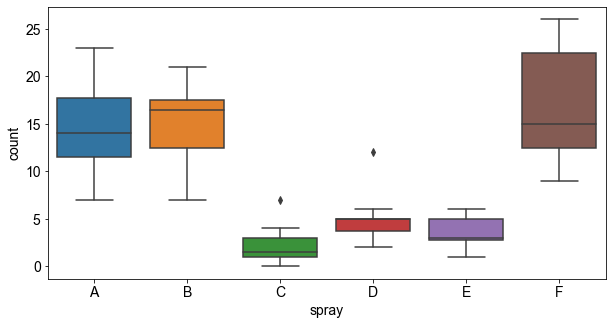

In [22]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
seaborn.set_style('whitegrid')
seaborn.boxplot(x='spray', y='count', data=insect_sprays, ax=ax)
plt.show()

In [23]:
def testStat(a, b, groups):
    return np.mean([y for (x, y) in zip(a, b) if x == groups[0]]) \
        - np.mean([y for (x, y) in zip(a, b) if x == groups[1]])
    
groups = ['B', 'C']
subdata = insect_sprays[insect_sprays.spray.isin(groups)]

observedStat = testStat(subdata['spray'], subdata['count'], groups)

n = subdata['spray'].values.shape[0]
nosims = 10000
permutations = np.array(list(map(
    lambda x: testStat(x, subdata['count'], groups),
    [np.random.choice(subdata['spray'].values, n) for i in range(nosims)]
)))

print(observedStat)
pValue = np.mean(permutations > observedStat)
print(pValue)

13.25
0.0


deviatia standard:  3.106314978780334
quantila 2.5%: -5.985714285714285
quantila 97.5%: 6.083333333333333


D:\Anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


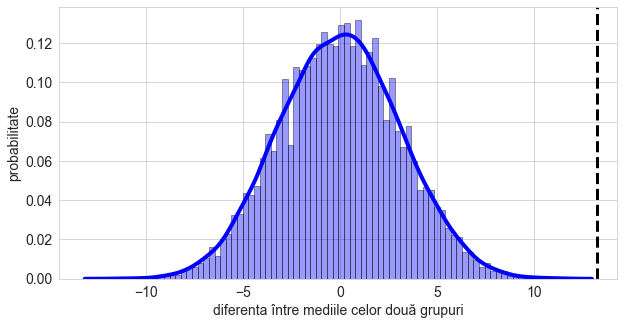

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
seaborn.distplot(permutations, hist=True, kde=True, bins=80, ax=ax,
    color = 'blue',  hist_kws={'edgecolor':'black'}, kde_kws={'linewidth': 4})
ax.grid(True)
ax.set_xlabel('diferenta între mediile celor două grupuri')
ax.set_ylabel('probabilitate')
ax.axvline(x=observedStat, lw=3, c='k', linestyle='--')

print('deviatia standard: ', np.std(permutations))
print('quantila 2.5%:', np.quantile(permutations, 0.025))
print('quantila 97.5%:', np.quantile(permutations, 0.975))
plt.show()

# Laborator

__Q1__. Power este o probabilitate pentru care se presupune că este adevărată:

1. ipoteza nulă $H_0$
2. ipoteza alternativă $H_a$
3. ambele

__Răspuns:__ 2

__Q2__. Pe măsură ce dimensiunea sample-ului crește, restul menținîndu-se constant, ce se întâmplă cu power?

1. se mărește
2. se micșorează
3. rămâne la fel
4. nu putem preciza

__Răspuns:__ 1

__Q3__. Ce se întâmplă cu power pe măsură ce $\mu_a$ se îndepărtează față de $\mu_0$ ?

__Răspuns:__ power creşte

__Q4__. În contextul calculului power, ce este 'effect size'?

__Răspuns:__ Effect size reprezintă diferenţa de medii în unităţi de deviaţie standard (unit free): $\frac{\mu_a - \mu_0}{\sigma}$

__Q5__. Presupunem că în cazul unei testări A/B, o schemă de publicitate a determinat o medie de 10 achiziții pe zi pentru un sample de 100 de zile, în timp ce pentru cealaltă a determinat o medie de 11 achiziții pe zi, pentru același interval de 100 de zile. Presupunem o deviație standard de 4 achiziții pe zi pentru ambele distribuții. 

Media de 10 achiziții/zi este $\mu_0$ asociată ipotezei nule, iar pentru ipoteza alternativă $\mu_a = 11$. Care ar fi power pentru un test T one-sided cu confidența de 95% ($\alpha=5\%$), în care presupunem că media achizițiilor a crescut la ipoteza alternativă?

In [25]:
mu_0 = 10
mu_a = 11
alpha = 0.05
sigma = 4
n = 100
z = stats.norm.ppf(1 - alpha)
print(stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc = mu_0, scale = sigma/np.sqrt(n)))
print(stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc = mu_a, scale = sigma/np.sqrt(n)))

0.050000000000000024
0.8037649400154938


__Q6__. Se dorește crearea unui studiu pentru detectarea valorii medii pe 4 ani a pierderii de volum a creierului, pierdere medie de 0.01 $mm^3$. Presupunem că deviația standard pe media acestor 4 ani este de 0.04 $mm^3$. Care este numărul de voluntari pe care trebuie să se facă studiul pentru un test 5% vs. ipoteza nulă că nu se pierde deloc volum, pentru a atinge power de 80% ?

In [26]:
mu_0 = 0
mu_a = 0.01
alpha = 0.05
sigma = 0.04
z = stats.norm.ppf(1 - alpha)

n = statsmodels.stats.power.tt_solve_power(
    effect_size = (mu_a - mu_0)/sigma, 
    alpha = alpha, 
    power = 0.8, 
    alternative='larger')

print(stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc = mu_0, scale = sigma/np.sqrt(n)))
print(stats.norm.sf(mu_0 + z * sigma/np.sqrt(n), loc = mu_a, scale = sigma/np.sqrt(n)))

print('Numărul de voluntari: ', int(n))

0.05000000000000005
0.8047578971639231
Numărul de voluntari:  100


__Q7__. Un studiu a observat asocierea mai multor factor nutriționali cu cancerul mamar (https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4166692/). Au fost calculate următoarele p-values:

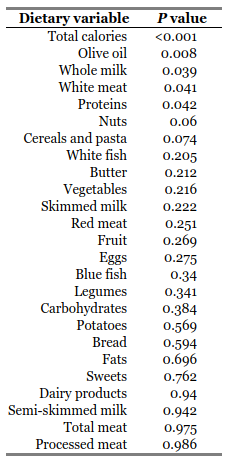

Considerăm un test cu 95% confidență.

__a)__ Fără corecție, care factori sunt relevanți statistic ?

__b)__ Aplicați corecția Bonferroni pe aceste p-values. Care din factori este statistic semnificativ?

__c)__ Aplicați corecția Benjamini/Hochberg. Care factori sunt relevanți statistic în acest caz?

Reprezentați grafic p-values cu corecția Bonferroni vs. p-values fără corecție, respectiv p-values cu corecția Benjamini/Hochberg vs. p-values fără corecție. Puneți pe ambele grafice și pragul de 0.05 ca să vedem ce rejectăm și ce nu.

In [27]:
pValue = np.array([0.001, 0.008, 0.039, 0.041, 0.042,
                   0.06, 0.074, 0.205, 0.212, 0.216,
                   0.222, 0.251, 0.269, 0.275, 0.34,
                   0.341, 0.384, 0.569, 0.594, 0.696,
                   0.762, 0.94, 0.942, 0.975, 0.986])

# a) Factorii relevanţi statistic sunt cei cărora le corespund un pValue mai mic decât 0.05:
# Total calories, olive oil, whole milk, white meat, proteins
print('Numărul factorilor relevanţi statistic: ', np.sum(pValue < 0.05))

Numărul factorilor relevanţi statistic:  5


In [28]:
adjustBonf = mt.multipletests(pValue, method='bonferroni')[1]
adjustBH = mt.multipletests(pValue, method='fdr_bh')[1]

rank = np.array(range(25)) + 1

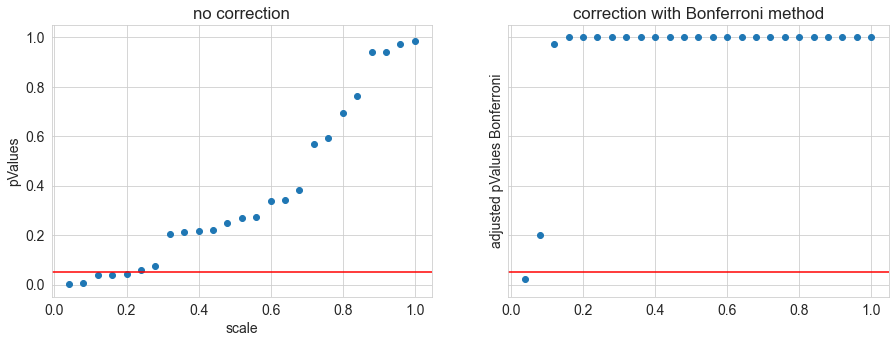

corecţie Bonferroni(FWER):  1


In [29]:
# b) Aplicăm corecţia Bonferroni
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax1.plot(rank/25, pValue, 'o')
ax1.axhline(y=0.05, c='r')
ax1.set_ylabel('pValues')
ax1.set_xlabel('scale')
ax1.set_title('no correction')

ax2.plot(rank/25, adjustBonf, 'o')
ax2.axhline(y=0.05, c='r')
ax2.set_ylabel('adjusted pValues Bonferroni')
ax2.set_title('correction with Bonferroni method')

plt.show()

print('corecţie Bonferroni(FWER): ' , np.sum(adjustBonf < 0.05))

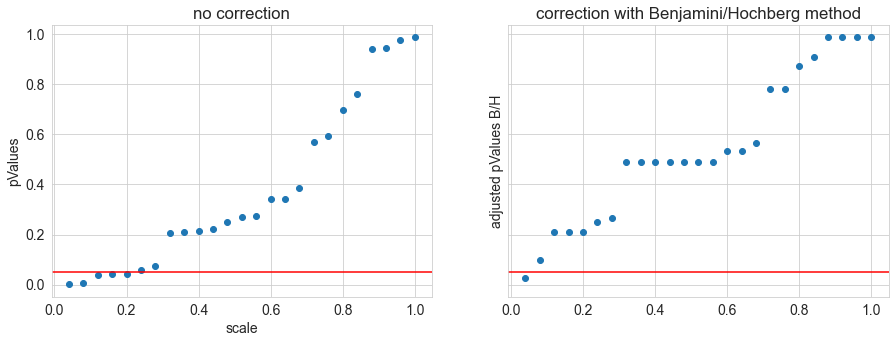

corecţie BH: 1


In [30]:
# c) Aplicăm corecţia Benjamini Hochberg
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax1.plot(rank/25, pValue, 'o')
ax1.axhline(y=0.05, c='r')
ax1.set_ylabel('pValues')
ax1.set_xlabel('scale')
ax1.set_title('no correction')

ax2.plot(rank/25, adjustBH, 'o')
ax2.axhline(y=0.05, c='r')
ax2.set_ylabel('adjusted pValues B/H')
ax2.set_title('correction with Benjamini/Hochberg method')

plt.show()

print('corecţie BH:' , np.sum(adjustBH < 0.05))

__Q8__. Ce folosește procedura bootstrap pentru a estima distribuția sampled a unei statistici ?

__Răspuns:__ Procedura bootstrap foloseşte resampling cu replacement pentru a estima distribuţia sampled a statisticii.

__Q9__.
__a)__ Ce fac testele de resampling? 

__Răspuns:__ Un test de permutare este un test exact, în care distribuţia observaţiilor este obţinută prin calcularea tuturor valorilor posibile ale data sample-ului observat, cu ajutorul resampling-ului.

__b)__ Care este ipoteza nulă și care este ipoteza alternativă?

__Răspuns:__ Considerăm ipoteza nulă: distribuţiile observaţiilor din fiecare grup sunt identice (una şi aceeaşi distribuţie), iar ipoteza alternativă: distribuţiile observaţiilor din fiecare grup nu sunt identice.

__c)__ Care este p-value?

__Răspuns:__ p-value al ipotezei este estimat ca proporţie de permutări care dau o diferenţă mai mare sau egală cu diferenţa mediilor ale sample-ului original.

__Q10__.
Realizați două grupuri de numere eșantionate din două distribuții, de medii 10 și respectiv 15, și dispersie 2. Etichetați fiecare sample cu numele grupului, A sau B. Grupurile au dimensiunile 40 și respectiv 50.

Ridicați whiskers plots pentru ambele grupuri.

__a)__ Realizați testul de permutare pentru a arăta dacă numerele sunt sau nu extrase din aceeași distribuție. Stabiliți care este ipoteza nulă și care este ipoteza alternativă. Afișați distribuția mediei resample-urilor. Ce p-value obțineți pentru statistica de tip medie? Care este rezultatul testului ipotezei?

__b)__ Creșteți dispersia grupurilor de la 2 la 10 și reluați experimentul. Ce constatați?

__Răspuns:__ Am observat următorul lucru: cu cât variaţia este mai mare, cu atât valoarea observată se apropie de/intră în distribuţia resample-ului (power scade).

In [31]:
def getGroup(var, mean, n_obs):
    return np.sqrt(var) * np.random.randn(n_obs) + mean

# A, B când dispersia este 2
A = getGroup(2, 10, 40)
B = getGroup(2, 15, 50)

# C, D când dispersia este 10
C = getGroup(10, 10, 40)
D = getGroup(10, 15, 50)

# Creăm coloana cu grupurile de numere eşantionate
numbers = np.append(A, B)
numbers = np.append(numbers, C)
numbers = np.append(numbers, D)
  
groups = np.append(['A'] * A.size, ['B'] * B.size)
groups = np.append(groups, ['C'] * C.size)
groups = np.append(groups, ['D'] * D.size)

# Creăm setul de date
data = pd.DataFrame(np.column_stack((numbers, groups)), columns = ['number', 'group'])
data.explode('number')
data['number'] = data['number'].astype('float')
print(data)

        number group
0    11.097535     A
1     9.451669     A
2    10.338934     A
3    10.233627     A
4    11.649842     A
..         ...   ...
175  18.707158     D
176  14.600884     D
177  12.515405     D
178  10.281099     D
179  14.121795     D

[180 rows x 2 columns]


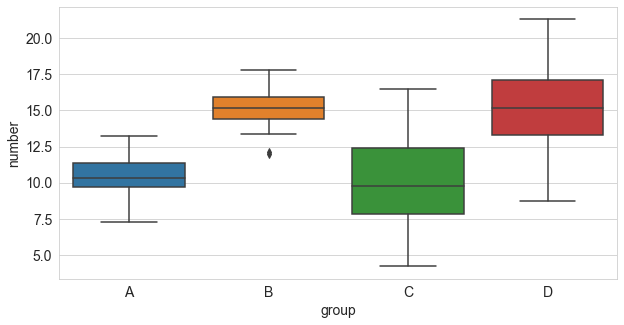

In [32]:
# Whiskers plots pentru grupurile A, B, C şi D

fig, ax = plt.subplots(1, 1, figsize = (10, 5))
seaborn.set_style('whitegrid')
seaborn.boxplot(x = 'group', y = 'number', data = data, ax = ax)
plt.show()

In [33]:
# Test de permutare A vs B

def testStat(a, b, groups):
    return np.mean([y for (x, y) in zip(a, b) if x == groups[0]]) - np.mean([y for (x, y) in zip(a, b) if x == groups[1]])

groups = ['A', 'B']
subdata = data[data.group.isin(groups)]
observedStat = testStat(subdata['group'], subdata['number'], groups)

n = subdata['group'].values.shape[0]
nosims = 10000
permutations = np.array(list(map(
    lambda x: testStat(x, subdata['number'], groups),
    [np.random.choice(subdata['group'].values, n) for i in range(nosims)])))

print('pValue pentru statistica de tip medie: ', np.mean(permutations > observedStat))
print('Rezultatul testului ipotezei: ', observedStat)

pValue pentru statistica de tip medie:  1.0
Rezultatul testului ipotezei:  -4.8165374744892535


D:\Anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


deviaţia standard:  0.5901869830428667
quantila 2.5%: -1.1498715387675273
quantila 97.5%: 1.1611158298715702


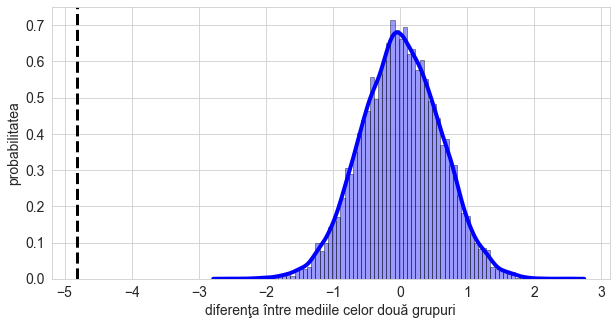

In [34]:
# Distribuţia resample-urilor a grupurilor A şi B

fig, ax = plt.subplots(1, 1, figsize = (10, 5))
seaborn.distplot(permutations, hist = True, kde = True, bins = 80, ax = ax,
                 color = 'blue', hist_kws = {'edgecolor' : 'black'}, kde_kws = {'linewidth' : 4})
ax.grid(True)
ax.set_xlabel('diferenţa între mediile celor două grupuri')
ax.set_ylabel('probabilitatea')
ax.axvline(x = observedStat, lw = 3, c = 'k', linestyle = '--')

print('deviaţia standard: ', np.std(permutations))
print('quantila 2.5%:', np.quantile(permutations, 0.025))
print('quantila 97.5%:', np.quantile(permutations, 0.975))
plt.show()

In [35]:
# Test de permutare C vs D

groups = ['C', 'D']
subdata = data[data.group.isin(groups)]
observedStat = testStat(subdata['group'], subdata['number'], groups)

n = subdata['group'].values.shape[0]
nosims = 10000
permutations = np.array(list(map(
    lambda x: testStat(x, subdata['number'], groups),
    [np.random.choice(subdata['group'].values, n) for i in range(nosims)])))

print('pValue pentru statistica de tip medie: ', np.mean(permutations > observedStat))
print('Rezultatul testului ipotezei: ', observedStat)

pValue pentru statistica de tip medie:  1.0
Rezultatul testului ipotezei:  -5.353836780870621


deviaţia standard:  0.8502555386007745


D:\Anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


quantila 2.5%: -1.6679939933457733
quantila 97.5%: 1.6429132653344152


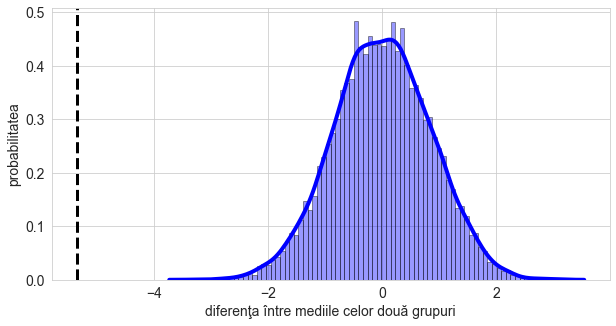

In [36]:
# Distribuţia resample-urilor a grupurilor C şi D

fig, ax = plt.subplots(1, 1, figsize = (10, 5))
seaborn.distplot(permutations, hist = True, kde = True, bins = 80, ax = ax,
                 color = 'blue', hist_kws = {'edgecolor' : 'black'}, kde_kws = {'linewidth' : 4})
ax.grid(True)
ax.set_xlabel('diferenţa între mediile celor două grupuri')
ax.set_ylabel('probabilitatea')
ax.axvline(x = observedStat, lw = 3, c = 'k', linestyle = '--')

print('deviaţia standard: ', np.std(permutations))
print('quantila 2.5%:', np.quantile(permutations, 0.025))
print('quantila 97.5%:', np.quantile(permutations, 0.975))
plt.show()